# Initializing Julia

In [1]:
using Revise
using InteractiveUtils

const PATH_AUGMENT_QOG_JL = "phase0/functions/qog_augmented_standard.jl"

# Print a summary of all dataframes that are current loaded in Main
function dataframe_summaries(mod=Main)
    for n in names(mod)
        x = getfield(mod, n)
        if x isa AbstractDataFrame
            println("=== DataFrame: ", n, " ===")
            println(summary(x))
            println()
        end
    end
end

includet(PATH_AUGMENT_QOG_JL)

# Aquiring the Quality of Governance Data

In [2]:
# download_qog_sources(PATH_DATA_DIR, QOG_SOURCES)

# Preprocessing the Data

In [8]:

# Extracts metadata labels and defines initial prefixes directly from the raw Stata source.
generate_raw_manifest(PATH_TS_STRATA_RAW, PATH_MANIFEST_SRC);

✓ Raw Manifest Created: data/qog_metadata_manifest.csv
  - Extracted 2009 raw definitions.
  - Identified 119 unique source prefixes.


In [9]:

# Converts all QoG CSV files referenced by sources to Arrow files in the same directory.
# Lowercases column names before writing. Skips conversion if the Arrow file already 
# exists unless force=true.
convert_csv_to_arrow(force=false)

[ Info: Skipping (Arrow exists): qog_std_ts_jan25.arrow


(converted = String[], skipped = ["qog_std_ts_jan25.arrow"], missing = String[], failed = Dict{String, String}(), skipped_noncsv = ["qog_std_cs_jan25.dta", "codebook_std_jan25.pdf"], data_dir = "/home/jovyan/work/data/")

In [10]:

# 1. Load with rowid assignment
df_ident = load_raw_ident(PATH_TS_RAW);

## SPINE DIAGNOSTICS 

In [11]:

# Diagnose spine issues (missing ccode or year)
issues = diagnose_spine_issues(df_ident);

>>> SPINE DIAGNOSTIC REPORT
    Total rows with spine issues: 234

    By issue type:
      MISSING_CCODE_ONLY: 234

    Problematic entities (non-blank rows):
      - ETH (Ethiopia): 47 rows, MISSING_CCODE_ONLY
      - YEM (Yemen): 44 rows, MISSING_CCODE_ONLY
      - DEU (Germany): 42 rows, MISSING_CCODE_ONLY
      - MHL (Marshall Islands) [COW: 983]: 38 rows, MISSING_CCODE_ONLY
      - VDR (Vietnam, South): 22 rows, MISSING_CCODE_ONLY
      - VNM (Vietnam, North): 22 rows, MISSING_CCODE_ONLY
      - SCG (Serbia and Montenegro): 14 rows, MISSING_CCODE_ONLY
      - XTI (Tibet): 5 rows, MISSING_CCODE_ONLY


In [12]:

# Audit for shadow identity variables (violations of namespace rules)
shadow_vars = audit_shadow_identities(df_ident);

✅ CLEAN: No shadow identity variables detected in df_std.


## HISTORICAL CCODE RESCUE       

In [14]:

# Step 1: Check for collisions BEFORE rescue
collisions = diagnose_ccode_collisions(df_ident);

ℹ️  INTENTIONAL COLLISIONS (1) — resolved by COLLISION_PRIORITY_ALPHAS:
   VDR → 704 merges with VNM

❌ CCODE COLLISION CONFLICTS DETECTED (1):
   SCG → 688 CONFLICTS with SRB (Serbia)

   These mappings would overwrite existing country data!


In [15]:

# Step 2: Preview what collisions will occur
# Show year details
preview = preview_rescue_collisions(df_ident; show_years=true);

>>> RESCUE COLLISION PREVIEW (informational — NO rows will be deleted):
    Total (ccode, year) pairs with >1 row: 22

    By entity combination:
      VDR + VNM: 22 years (1955-1976)
        Years: 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976

    NOTE: Use `ggis_rowid` as unique key, or (ident_ccode, ident_year, ident_ccodealp)


In [16]:

# Step 3: Apply rescue (if no conflicts)
df_rescued = rescue_historical_ccodes(df_ident; verbose=true);

>>> Historical Ccode Rescue:
    Missing before: 234
    Rescued: 234
    Missing after: 0
    Row count: 12391 (unchanged)
    By alpha code:
      ETH → 231: 47 rows
      YEM → 887: 44 rows
      DEU → 276: 42 rows
      MHL → 584: 38 rows
      VNM → 704: 22 rows
      VDR → 704: 22 rows
      SCG → 688: 14 rows
      XTI → 9156: 5 rows

    ℹ️  Spine collisions detected (NOT resolved — rows preserved):
       Unique (ccode, year) pairs with >1 row: 44
       Total rows involved: 44
       By entity combination:
         VDR + VNM: 22 years (1955-1976)
           Names: Vietnam, North + Vietnam, South


## Region Standardization

In [17]:

# Standardize regions (requires rescued data)
df_regions = standardize_regions(df_rescued; verbose=true);

# Check coverage
n_missing = count(ismissing, df_regions.ggis_region)
println("Missing regions: $n_missing / $(nrow(df_regions))")

✓ ggis_rowid verified unique: 12391 rows
    ℹ️  Rows in spine collisions: 44 (preserved — use ggis_rowid)
  - Initial missing regions: 253 / 12391
  - Imputed from same ccode: 253
  - Final missing regions: 0 / 12391

✅ Regions standardized to 'ggis_region'
   Primary key: ggis_rowid (always unique)
Missing regions: 0 / 12391


In [18]:

# List entities without region assignment
orphans = list_region_orphans(df_regions);

✓ No region orphans found.


In [30]:

# 9. Verify row preservation
@assert nrow(df_regions) == nrow(df_ident) "Row count mismatch!"
@assert allunique(df_regions.ggis_rowid) "ggis_rowid not unique!"

## CARTOGRAPHIC LOOKUP    

In [20]:

# Generate cartographic lookup needed for proper mapping
carto = generate_cartographic_lookup(df_regions);

# Inspect
# first(carto, 10)

>>> Generated cartographic lookup: 207 entities
    From QoG: 202
    Supplemental territories: 7


## ARROW SLUG EXTRACTION

In [22]:

# Extract slugs from augmented data
slugs_df = extract_arrow_slugs(df_regions, save_path=PATH_ARROW_SLUGS);


>>> Extracting slugs from Arrow DataFrame...
    Extracted 2013 slugs
    Saved to: data/ggis_arrow_slugs.csv

    By prefix:
      wdi: 270
      eu: 239
      oecd: 192
      aii: 64
      cpds: 49
      iaep: 48
      jw: 48
      wvs: 46
      bti: 44
      opri: 41
      ... and 107 more

    By type:
      continuous: 1569
      discrete: 262
      binary: 121
      categorical: 56
      string: 5


## VALIDATION UTILITIES  

In [28]:

const PATH_PDF_SLUGS = "./data/qog_slugs.csv"

# Validate ident schema of an adjunct file
is_valid = validate_ident_schema(PATH_ARROW_SLUGS);
is_valid = validate_ident_schema(PATH_MANIFEST_SRC);
is_valid = validate_ident_schema(PATH_PDF_SLUGS);

✓ Namespace verified: data/ggis_arrow_slugs.csv
✓ Namespace verified: data/qog_metadata_manifest.csv
✓ Namespace verified: ./data/qog_slugs.csv


# Map the Regions

In [31]:
carto_lookup = generate_cartographic_lookup(df_regions);

>>> Generated cartographic lookup: 207 entities
    From QoG: 202
    Supplemental territories: 7


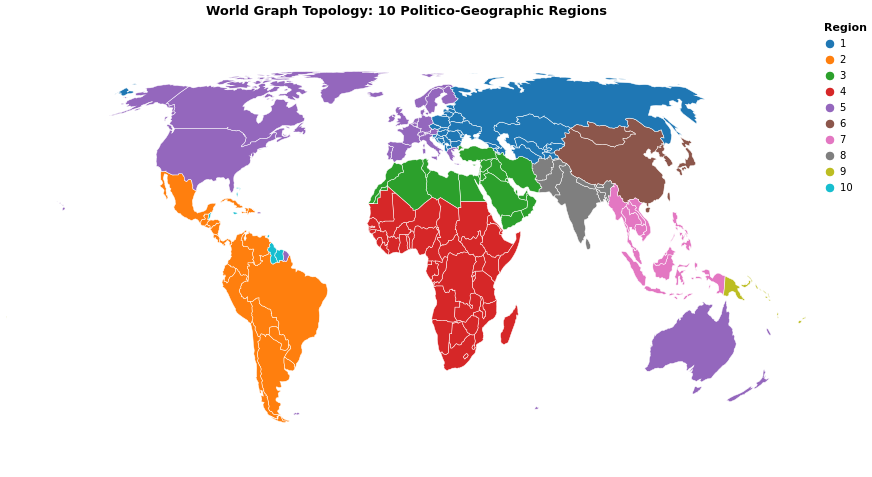

In [32]:

# Map it
@vlplot(
    width=800, height=450,
    title="World Graph Topology: 10 Politico-Geographic Regions",
    layer=[{
        data={values=dataset("world-110m"), format={type=:topojson, feature=:countries}},
        projection={type=:equalEarth},
        transform=[
            {filter="datum.id != 10"},
            {filter="datum.id != -99"},
            {lookup=:id, from={data=carto_lookup, key=:ident_ccode, fields=[:ht_region, :ident_cname]}}
        ],
        mark={type=:geoshape, stroke=:white, strokeWidth=0.5},
        encoding={
            color={field=:ht_region, type=:nominal, scale={scheme=:category10}, legend={title="Region"}},
            tooltip=[{field=:ident_cname, type=:nominal, title="Country"}, {field=:ht_region, type=:nominal, title="Region"}]
        }
    }]
)

# Building the slug manifest

## Add to metadata

| Column Name       | Definition                                                                 | Role in Culling/Selection                                                                 |
|-------------------|-----------------------------------------------------------------------------|---------------------------------------------------------------------------------------------|
| ggis_birth_year        | The earliest year globally that reports data for this slug.      | Identifies Anchors vs. Innovators.                                                        |
| ggis_death_year        | The latest year globally that reports data for this slug.                        | Filters out "Depleted" slugs (e.g., old gle_ indicators).                                 |
| data_nature       | The classification of the data source: Official, Imputed, or Expert.     | Prevents the "Sparsity Trap" by protecting official reporting signals.                     |
| primary_citation  | The formal institutional or academic citation for the methodological source. | Provides the audit trail and Methodological Grounding for your model.                      |


# Building the metadata and prefix manifests

In [82]:
# 1. Load Data
manifest = CSV.read(PATH_MANIFEST_SRC, DataFrame)
slug_col = :Variable

:Variable

In [47]:
"""
    standardize_manifest_identifiers!(manifest)

Renames structural prefixes (base/ccode) to 'ident' and updates the slug names
to match the standardized 'ident_' naming convention used in df_aug.
"""
function standardize_manifest_identifiers!(manifest::DataFrame)
    # Define prefixes to be migrated
    target_prefixes = ["base", "ccode", "cname", "ccodealp"]

    for row in eachrow(manifest)
        if row.prefix in target_prefixes
            # 1. Update the prefix to 'ident'
            row.prefix = "ident"
            
            # 2. Update the slug to the standardized version if it's not already
            if !startswith(row.slug, "ident_")
                row.slug = "ident_$(row.slug)"
            end
        end
    end
    return manifest
end

standardize_manifest_identifiers!

In [36]:
"""
    process_full_metadata(raw_slug, manifest)

Renames the manifest columns to lowercase and changes the primary 
identifier column (raw_slug) to "slug".
"""
function process_full_metadata(raw_slug, manifest)
    # 1. Check if it's already been processed
    # We check both the symbol :slug and the string "slug" to be safe
    if :slug in propertynames(manifest) || "slug" in names(manifest)
        println("Note: Manifest already has a :slug column. Skipping rename.")
        return manifest
    end

    # 2. Standardize names to lowercase Symbols
    new_names = Symbol.(lowercase.(string.(names(manifest))))
    df_meta = rename(manifest, new_names)

    # 3. Identify the target to become :slug
    target = Symbol(lowercase(string(raw_slug)))

    # 4. Final Safety: Check if the target actually exists
    if !(target in propertynames(df_meta))
        error("Target column :$target not found. Available: $(propertynames(df_meta))")
    end

    rename!(df_meta, target => :slug)

    return df_meta
end

# HOW TO CALL IT:
# clean_manifest = process_full_metadata(:Variable, manifest)

process_full_metadata

In [83]:
println(propertynames(manifest))
nrow(manifest)

[:Variable, :Label, :Prefix]


2009

In [84]:
manifest = process_full_metadata(slug_col, manifest)
manifest = standardize_manifest_identifiers!(manifest)
println(propertynames(manifest))
nrow(manifest)

[:slug, :label, :prefix]


2009

In [81]:
"""
    audit_ggis_years_final(df_aug, manifest)

Audits temporal coverage by scanning data variables via stack 
and handling system identifiers via direct column analysis.
"""
function audit_ggis_years(df_aug::DataFrame, manifest::DataFrame)
    # 1. Capture Global Temporal Bounds from the anchor
    global_start = minimum(df_aug.ident_year)
    global_end = maximum(df_aug.ident_year)

    # 2. Identify Identity vs Data columns in the manifest
    # Everything in the 'ident' prefix gets the global range automatically
    is_ident = (manifest.prefix .== "ident") .| startswith.(manifest.slug, "ident_")
    
    # Pre-fill ident rows with global bounds
    manifest.ggis_birth_year = Vector{Union{Int, Missing}}(missing, nrow(manifest))
    manifest.ggis_death_year = Vector{Union{Int, Missing}}(missing, nrow(manifest))
    
    manifest[is_ident, :ggis_birth_year] .= global_start
    manifest[is_ident, :ggis_death_year] .= global_end

    # 3. Audit the rest (Actual Data)
    # We only stack columns that are NOT in the ident list
    data_slugs = Symbol.(manifest[.!is_ident, :slug])
    # Only audit slugs that actually exist as columns in df_aug
    valid_data_cols = intersect(data_slugs, propertynames(df_aug))
    
    if !isempty(valid_data_cols)
        df_long = stack(df_aug, valid_data_cols, [:ident_year], 
                        variable_name=:slug, value_name=:val)
        dropmissing!(df_long, :val)
        
        df_bounds = combine(groupby(df_long, :slug), 
            :ident_year => minimum => :birth,
            :ident_year => maximum => :death
        )
        
        # 4. Map the audited bounds back to the manifest
        # We use a dictionary for O(1) lookup speed
        birth_map = Dict(string(r.slug) => r.birth for r in eachrow(df_bounds))
        death_map = Dict(string(r.slug) => r.death for r in eachrow(df_bounds))
        
        for row in eachrow(manifest)
            if !is_ident[rownumber(row)] && haskey(birth_map, row.slug)
                row.ggis_birth_year = birth_map[row.slug]
                row.ggis_death_year = death_map[row.slug]
            end
        end
    end
    
    return manifest
end

audit_ggis_years

In [85]:
manifest = audit_ggis_years(df_aug, manifest);

In [72]:
"""
    check_audit_coverage(manifest)

Identifies and summarizes manifest entries that lack temporal coverage data.
"""
function check_audit_coverage(manifest::DataFrame)
    # Filter for entries where the audit failed
    zombies = filter(row -> ismissing(row.ggis_birth_year), manifest)
    
    total = nrow(manifest)
    zombie_count = nrow(zombies)
    valid_count = total - zombie_count
    
    println("📊 Audit Summary:")
    println("- Total Slugs in Manifest: $total")
    println("- Successfully Audited:    $valid_count")
    println("- Missing Data (Zombies):  $zombie_count")
    
    if zombie_count > 0
        println("\n⚠️ First 10 Slugs with missing coverage:")
        display(first(zombies[:, [:slug, :label, :prefix]], 20))
    end
    
    return zombies
end

# Run the check
# zombie_df = check_audit_coverage(manifest)

check_audit_coverage

In [86]:
zombie_df = check_audit_coverage(manifest);

📊 Audit Summary:
- Total Slugs in Manifest: 2009
- Successfully Audited:    2000
- Missing Data (Zombies):  9

⚠️ First 10 Slugs with missing coverage:


Row,slug,label,prefix
,String31,String?,String15
1,eu_edurstterISCED02f,Population 15-64 with ISCED level 0-2 as % of total population (Female),eu
2,eu_edurstterISCED02m,Population 15-64 with ISCED level 0-2 as % of total population (Male),eu
3,eu_edurstterISCED02t,Population 15-64 with ISCED level 0-2 as % of total population (Total),eu
4,eu_edurstterISCED34f,Population 15-64 with ISCED level 3-4 as % of total population (Female),eu
5,eu_edurstterISCED34m,Population 15-64 with ISCED level 3-4 as % of total population (Male),eu
6,eu_edurstterISCED34t,Population 15-64 with ISCED level 3-4 as % of total population (Total),eu
7,eu_edurstterISCED58f,Population 15-64 with ISCED level 5-8 as % of total population (Female),eu
8,eu_edurstterISCED58m,Population 15-64 with ISCED level 5-8 as % of total population (Male),eu
9,eu_edurstterISCED58t,Population 15-64 with ISCED level 5-8 as % of total population (Total),eu


In [87]:
# 1. Check if the column even exists in the data
exists_in_data = :eu_edurstterISCED02f in propertynames(df_aug)
println("Does slug exist in df_aug? ", exists_in_data)

if exists_in_data
    # 2. If it exists, check the actual count of non-missing values
    non_missing_count = count(!ismissing, df_aug.eu_edurstterISCED02f)
    println("Count of non-missing values: ", non_missing_count)
    
    # 3. If count > 0, something is wrong with the audit. 
    # If count == 0, the audit is correct: it's a dead variable.
else
    println("The column is missing entirely from the augmented dataset.")
end

Does slug exist in df_aug? false
The column is missing entirely from the augmented dataset.


In [88]:
# Forensic check for a specific 'Zombie' slug
test_slug = :eu_edurstterISCED02f

if test_slug in propertynames(df_aug)
    actual_data = df_aug[!, test_slug]
    n_valid = count(!ismissing, actual_data)
    unique_years = unique(df_aug[.!ismissing.(actual_data), :ident_year])
    
    println("🔍 Forensic Report for $test_slug:")
    println("- Observations found: $n_valid")
    println("- Years covered:      $(sort(unique_years))")
else
    println("❌ ERROR: The slug $test_slug does not exist in df_aug.")
end

❌ ERROR: The slug eu_edurstterISCED02f does not exist in df_aug.


In [95]:
function check_csv_headers(path, target_slug)
    if !isfile(path)
        println("❌ File not found at: $path")
        return
    end

    open(path, "r") do io
        # Read the first line and handle potential BOM/nulls
        header_line = readline(io)
        header_line = replace(header_line, "\ufeff" => "") # Remove BOM
        header_line = replace(header_line, "\0" => "")    # Remove Nulls
        
        # Split and clean
        headers = [strip(replace(h, "\"" => "")) for h in split(header_line, ",")]
        
        println("📊 CSV Headers found: ", length(headers))
        
        if target_slug in headers
            println("✅ Success: '$target_slug' exists in the RAW CSV!")
        else
            println("❌ Not found in CSV.")
            # Check for name variations
            matches = filter(h -> contains(lowercase(h), "edurstter"), headers)
            !isempty(matches) && println("💡 Similar slugs in CSV: ", matches)
        end
    end
end

# Check the specific Eurostat slug
check_csv_headers("data/qog_std_ts_jan25.csv", "eu_edurstterISCED02f")

📊 CSV Headers found: 2009
❌ Not found in CSV.
💡 Similar slugs in CSV: SubString{String}["eu_edurstterisced02f", "eu_edurstterisced02m", "eu_edurstterisced02t", "eu_edurstterisced34f", "eu_edurstterisced34m", "eu_edurstterisced34t", "eu_edurstterisced58f", "eu_edurstterisced58m", "eu_edurstterisced58t"]


In [93]:
function universal_header_check(path, target)
    # Read the raw bytes
    raw_bytes = read(path)
    
    # Filter out null bytes and BOMs that cause the \xff and \0 errors
    # 0x00 is null, 0xff/0xfe are common UTF-16 BOMs
    clean_bytes = filter(b -> b != 0x00 && b != 0xff && b != 0xfe, raw_bytes)
    
    # Convert to String safely
    full_text = String(clean_bytes)
    
    # Get just the first line
    first_line = split(full_text, ['\n', '\r'], keepempty=false)[1]
    
    # Split headers and clean quotes
    headers = [strip(replace(h, "\"" => "")) for h in split(first_line, ",")]
    
    println("📊 Headers found: ", length(headers))
    
    if target in headers
        println("✅ Success: Found '$target'!")
    else
        println("❌ Still not in headers.")
        matches = filter(h -> contains(lowercase(h), "edurstter"), headers)
        !isempty(matches) && println("💡 Similar names in file: ", matches)
    end
end

universal_header_check(PATH_TS_RAW, "eu_edurstterISCED02f")

📊 Headers found: 1
❌ Still not in headers.


LoadError: Base.InvalidCharError{Char}('\xaf')

In [12]:
function process_full_metadata(raw_slug, df_std)
    slug_str = string(raw_slug)
    
    # Resolve the actual column name in df_std
    target_col = get(IDENT_MAPPING, slug_str, slug_str)
    
    # Safety: If the column doesn't exist in the data, skip temporal audit
    if !(target_col in names(df_std))
        return (missing, missing)
    end

    # Global Scan: Find every year where this variable has data
    signal_years = df_std[.!ismissing.(df_std[!, target_col]), :ident_year]
    
    if isempty(signal_years)
        return (missing, missing)
    end
    
    return (minimum(signal_years), maximum(signal_years))
end

process_full_metadata (generic function with 1 method)

In [41]:
# # 3. CORRECT CALL: Iterate rows of manifest, but scan df_std
# results = [process_full_metadata(row.Variable, df_aug) for row in eachrow(manifest)]

# # 4. Populate Manifest
# manifest.ggis_birth_year = [r[1] for r in results]
# manifest.ggis_death_year = [r[2] for r in results]

# println("✓ Manifest Temporal Audit Complete using Global Signal Scan.")

In [28]:
println(propertynames(manifest))
nrow(manifest)

[:Variable, :Label, :Prefix]


2009

In [247]:
function transform_manifest(manifest_src_path, df_std, manifest_result_path)
    manifest = CSV.read(manifest_src_path, DataFrame)

    # Pre-allocate / ensure columns exist
    manifest.Prefix = Vector{String}(undef, nrow(manifest))
    manifest.ggis_birth_year = Vector{Union{Int, Missing}}(missing, nrow(manifest))
    manifest.ggis_death_year = Vector{Union{Int, Missing}}(missing, nrow(manifest))
    manifest.data_nature = Vector{String}(undef, nrow(manifest))
    manifest.primary_citation = Vector{String}(undef, nrow(manifest))

    for i in 1:nrow(manifest)
        raw_slug = string(manifest[i, :Variable])

        # A. Resolve Standardized Name
        target_col = get(IDENT_MAPPING, raw_slug, raw_slug)
        manifest[i, :Variable] = target_col

        # B. Resolve Prefix
        prefix = haskey(IDENT_MAPPING, raw_slug) ? "ident" : split(target_col, "_")[1]
        manifest[i, :Prefix] = prefix

        # C. Global Temporal Scan
        birth, death = process_full_metadata(raw_slug, df_std)
        manifest[i, :ggis_birth_year] = birth
        manifest[i, :ggis_death_year] = death

        # D. Metadata Lookup
        nature, citation = get(prefix_registry, prefix, ("Unknown", "Manual Review Required"))
        manifest[i, :data_nature] = nature
        manifest[i, :primary_citation] = citation
    end

    # CSV.write(manifest_result_path, manifest)
    println("✓ Manifest transformed and saved to: $manifest_result_path")
    return manifest
end


transform_manifest (generic function with 1 method)

In [237]:
function transform_manifest(manifest_src_path, df_std, manifest_result_path)
    # Load raw metadata
    manifest = CSV.read(manifest_src_path, DataFrame)
    
    # Pre-allocate columns
    manifest.Prefix = Vector{String}(undef, nrow(manifest))
    manifest.ggis_birth_year = Vector{Union{Int, Missing}}(missing, nrow(manifest))
    manifest.ggis_death_year = Vector{Union{Int, Missing}}(missing, nrow(manifest))
    manifest.data_nature = Vector{String}(undef, nrow(manifest))
    manifest.primary_citation = Vector{String}(undef, nrow(manifest))

    for i in 1:nrow(manifest)
        raw_slug = string(manifest[i, :Variable])
        
        # A. Resolve Standardized Name
        target_col = get(IDENT_MAPPING, raw_slug, raw_slug)
        manifest[i, :Variable] = target_col # Update manifest to ident_ namespace
        
        # B. Resolve Prefix
        prefix = haskey(IDENT_MAPPING, raw_slug) ? "ident" : split(target_col, "_")[1]
        manifest[i, :Prefix] = prefix

        # C. Global Temporal Scan (Birth/Death)
        birth, death = process_full_metadata(raw_slug, df_std)
        manifest[i, :ggis_birth_year] = birth
        manifest[i, :ggis_death_year] = death

        # D. Metadata Lookup from Registry Dict
        nature, citation = get(prefix_registry, prefix, ("Unknown", "Manual Review Required"))
        manifest[i, :data_nature] = nature
        manifest[i, :primary_citation] = citation
    end

    # CSV.write(manifest_result_path, manifest)
    println("✓ Manifest transformed and saved to: $manifest_result_path")
    return manifest
end

transform_manifest (generic function with 1 method)

In [249]:
manifest = transform_manifest(manifest_src_path, df_std, manifest_result_path)
println(names(manifest))

✓ Manifest transformed and saved to: data/ggis_metadata_manifest.csv
["Variable", "Label", "Prefix", "ggis_birth_year", "ggis_death_year", "data_nature", "primary_citation"]


In [206]:
function generate_fidelity_registry(df_std::DataFrame, manifest::DataFrame, output_path::String)
    # 1. Isolate Analytical Prefixes
    prefixes = unique(manifest.Prefix)
    filter!(p -> !(p in ["ident", "ggis"]), prefixes)
    
    registry_rows = []

    for p in prefixes
        p_str = String(p)
        
        # 2. FIX: Pass the manifest to trigger the Dynamic Audit Year logic
        # This ensures prefixes like "aid" are audited at their death year (2013)
        report, classification = audit_prefix_fidelity(df_std, manifest, p_str)
        
        # 3. Construct the Intensity Map
        map_parts = String[]
        for r_id in 1:10
            reg_row = filter(r -> r.ht_region == r_id, report)
            fid = isempty(reg_row) ? 0.0 : reg_row.Fidelity_Pct[1]
            push!(map_parts, "R$(lpad(r_id, 2, '0')) => $(fid)")
        end
        
        global_fid = report[report.ht_region .== 0, :Fidelity_Pct][1]
        push!(map_parts, "global => $(global_fid)")
        
        # 4. Enhance the Map with Temporal Status
        # We look up the death year again just for the registry label
        prefix_meta = manifest[manifest.Prefix .== p, :]
        max_death = maximum(skipmissing(prefix_meta.death_year))
        status_tag = max_death < 2018 ? "INACTIVE (Died $max_death)" : "ACTIVE"
        
        fidelity_map = "[ $status_tag | " * join(map_parts, ", ") * " ]"
        
        # 5. Extract Institutional Provenance
        meta_sample = prefix_meta[1, :]
        
        push!(registry_rows, (
            Prefix = p_str,
            Topology = classification,
            Fidelity_Map = fidelity_map,
            Nature = meta_sample.data_nature,
            Citation = meta_sample.primary_citation
        ))
    end
    
    # 6. Final Export
    registry = DataFrame(registry_rows)
    # CSV.write(output_path, registry) # Uncomment when ready to save
    
    println("✓ Fidelity Registry synchronized. Historical sensors (like 'aid') now correctly regionalized.")
    return registry
end

generate_fidelity_registry (generic function with 1 method)

In [211]:
audit_prefix_fidelity(df_std, manifest, "aid");


--- Fidelity Audit: aid (⚠️ INACTIVE (Died: 2013)) ---
Snapshot Year: 2013


Row,ht_region,Region_Name,Total_Countries,Signal_Countries,Fidelity_Pct
,Int64?,String?,Int64,Int64,Float64
1,1,Eastern Europe and post Soviet Union (including Central Asia),28,21,75.0
2,2,"Latin America (including Cuba, Haiti & the Dominican Republic)",19,19,100.0
3,3,"North Africa & the Middle East (including Israel, Turkey & Cyprus)",20,14,70.0
4,4,Sub-Saharan Africa,49,48,98.0
5,5,Western Europe and North America (including Australia & New Zealand),27,22,81.5
6,6,East Asia (including Japan & Mongolia),7,6,85.7
7,7,South-East Asia,11,9,81.8
8,8,South Asia,8,8,100.0
9,9,The Pacific (excluding Australia & New Zealand),12,12,100.0



Determined classification is: Global (G)


In [212]:
generate_fidelity_registry(df_std, manifest, prefix_grh_fidelity_path)


--- Fidelity Audit: aid (⚠️ INACTIVE (Died: 2013)) ---
Snapshot Year: 2013


Row,ht_region,Region_Name,Total_Countries,Signal_Countries,Fidelity_Pct
,Int64?,String?,Int64,Int64,Float64
1,1,Eastern Europe and post Soviet Union (including Central Asia),28,21,75.0
2,2,"Latin America (including Cuba, Haiti & the Dominican Republic)",19,19,100.0
3,3,"North Africa & the Middle East (including Israel, Turkey & Cyprus)",20,14,70.0
4,4,Sub-Saharan Africa,49,48,98.0
5,5,Western Europe and North America (including Australia & New Zealand),27,22,81.5
6,6,East Asia (including Japan & Mongolia),7,6,85.7
7,7,South-East Asia,11,9,81.8
8,8,South Asia,8,8,100.0
9,9,The Pacific (excluding Australia & New Zealand),12,12,100.0



Determined classification is: Global (G)

--- Fidelity Audit: aii (✅ ACTIVE) ---
Snapshot Year: 2018


Row,ht_region,Region_Name,Total_Countries,Signal_Countries,Fidelity_Pct
,Int64?,String?,Int64,Int64,Float64
1,1,Eastern Europe and post Soviet Union (including Central Asia),28,0,0.0
2,2,"Latin America (including Cuba, Haiti & the Dominican Republic)",19,0,0.0
3,3,"North Africa & the Middle East (including Israel, Turkey & Cyprus)",20,5,25.0
4,4,Sub-Saharan Africa,49,48,98.0
5,5,Western Europe and North America (including Australia & New Zealand),27,0,0.0
6,6,East Asia (including Japan & Mongolia),7,0,0.0
7,7,South-East Asia,11,0,0.0
8,8,South Asia,8,0,0.0
9,9,The Pacific (excluding Australia & New Zealand),12,0,0.0



Determined classification is: Regional (R)

--- Fidelity Audit: ajr (✅ ACTIVE) ---
Snapshot Year: 2018


...

Row,ht_region,Region_Name,Total_Countries,Signal_Countries,Fidelity_Pct
,Int64?,String?,Int64,Int64,Float64
1,1,Eastern Europe and post Soviet Union (including Central Asia),28,11,39.3
2,2,"Latin America (including Cuba, Haiti & the Dominican Republic)",19,6,31.6
3,3,"North Africa & the Middle East (including Israel, Turkey & Cyprus)",20,3,15.0
4,4,Sub-Saharan Africa,49,4,8.2
5,5,Western Europe and North America (including Australia & New Zealand),27,13,48.1
6,6,East Asia (including Japan & Mongolia),7,1,14.3
7,7,South-East Asia,11,2,18.2
8,8,South Asia,8,1,12.5
9,9,The Pacific (excluding Australia & New Zealand),12,0,0.0



Determined classification is: Hybrid (H)

--- Fidelity Audit: yri (✅ ACTIVE) ---
Snapshot Year: 2018


Row,ht_region,Region_Name,Total_Countries,Signal_Countries,Fidelity_Pct
,Int64?,String?,Int64,Int64,Float64
1,1,Eastern Europe and post Soviet Union (including Central Asia),28,4,14.3
2,2,"Latin America (including Cuba, Haiti & the Dominican Republic)",19,7,36.8
3,3,"North Africa & the Middle East (including Israel, Turkey & Cyprus)",20,2,10.0
4,4,Sub-Saharan Africa,49,4,8.2
5,5,Western Europe and North America (including Australia & New Zealand),27,4,14.8
6,6,East Asia (including Japan & Mongolia),7,1,14.3
7,7,South-East Asia,11,2,18.2
8,8,South Asia,8,2,25.0
9,9,The Pacific (excluding Australia & New Zealand),12,1,8.3



Determined classification is: Hybrid (H)
✓ Fidelity Registry synchronized. Historical sensors (like 'aid') now correctly regionalized.


Row,Prefix,Topology,Fidelity_Map,Nature,Citation
,String,String,String,String15,String
1,aid,Global (G),"[ INACTIVE (Died 2013) | R01 => 75.0, R02 => 100.0, R03 => 70.0, R04 => 98.0, R05 => 81.5, R06 => 85.7, R07 => 81.8, R08 => 100.0, R09 => 100.0, R10 => 76.9, global => 87.1 ]",Imputed,AidData v. 3.1 (AidData).
2,aii,Regional (R),"[ ACTIVE | R01 => 0.0, R02 => 0.0, R03 => 25.0, R04 => 98.0, R05 => 0.0, R06 => 0.0, R07 => 0.0, R08 => 0.0, R09 => 0.0, R10 => 0.0, global => 27.3 ]",Expert,Global Integrity (2024). Africa Integrity Indicators.
3,ajr,Hybrid (H),"[ ACTIVE | R01 => 0.0, R02 => 94.7, R03 => 20.0, R04 => 67.3, R05 => 25.9, R06 => 42.9, R07 => 63.6, R08 => 62.5, R09 => 16.7, R10 => 53.8, global => 44.3 ]",Imputed,"Acemoglu, D., et al. (2001). Colonial Origins."
4,atop,Global (G),"[ ACTIVE | R01 => 96.4, R02 => 100.0, R03 => 100.0, R04 => 98.0, R05 => 100.0, R06 => 85.7, R07 => 100.0, R08 => 87.5, R09 => 50.0, R10 => 100.0, global => 94.8 ]",Imputed,Alliance Treaty Obligations and Provisions (ATOP).
5,bci,Global (G),"[ ACTIVE | R01 => 100.0, R02 => 100.0, R03 => 100.0, R04 => 98.0, R05 => 92.6, R06 => 100.0, R07 => 100.0, R08 => 100.0, R09 => 100.0, R10 => 100.0, global => 98.5 ]",Expert,Standaert (2015). The Bayesian Corruption Index.
6,bicc,Hybrid (H),"[ ACTIVE | R01 => 92.9, R02 => 89.5, R03 => 75.0, R04 => 85.7, R05 => 81.5, R06 => 71.4, R07 => 90.9, R08 => 75.0, R09 => 16.7, R10 => 30.8, global => 76.8 ]",Expert,Bonn International Center for Conversion.
7,biu,Hybrid (H),"[ INACTIVE (Died 2014) | R01 => 96.4, R02 => 100.0, R03 => 95.0, R04 => 93.9, R05 => 92.6, R06 => 100.0, R07 => 100.0, R08 => 100.0, R09 => 33.3, R10 => 53.8, global => 89.2 ]",Expert,Fox (Religion and State Project / RAS).
8,bl,Hybrid (H),"[ INACTIVE (Died 2015) | R01 => 71.4, R02 => 100.0, R03 => 90.0, R04 => 63.3, R05 => 85.2, R06 => 85.7, R07 => 90.9, R08 => 87.5, R09 => 25.0, R10 => 38.5, global => 73.2 ]",Imputed,"Barro, R. J., & Lee, J. W. (2013). Educational Attainment."
9,bmr,Global (G),"[ ACTIVE | R01 => 100.0, R02 => 100.0, R03 => 100.0, R04 => 98.0, R05 => 100.0, R06 => 100.0, R07 => 100.0, R08 => 100.0, R09 => 100.0, R10 => 100.0, global => 99.5 ]",Imputed,"Boix, C., et al. (2013). Political Regimes."


### Verify all prefixes are covered

In [175]:
using DataFrames, CSV

"""
Extracts unique prefixes from 'Manual Review' rows and saves them to a CSV.
"""
function export_unknown_prefixes(manifest_path::String, output_path::String; slug_col=:Variable)
    # 1. Load the manifest
    if !isfile(manifest_path)
        error("Manifest file not found at $manifest_path")
    end
    df = CSV.read(manifest_path, DataFrame)
    
    # 2. Identify 'Unknown' or 'Manual Review' rows
    # We look for rows where the categorization logic fell through
    unknown_df = filter(row -> 
        (ismissing(row.data_nature) || row.data_nature == "Unknown") || 
        (ismissing(row.primary_citation) || row.primary_citation == "Manual Review"), 
        df
    )
    
    if nrow(unknown_df) == 0
        println("All prefixes categorized. No CSV generated.")
        return
    end
    
    # 3. Extract unique prefixes and their count (to prioritize high-volume datasets)
    # We get everything before the first underscore
    prefix_list = [split(string(row[slug_col]), "_")[1] for row in eachrow(unknown_df)]
    
    # 4. Create a summary DataFrame
    summary_df = combine(groupby(DataFrame(prefix = prefix_list), :prefix), nrow => :variable_count)
    sort!(summary_df, :variable_count, rev=true)
    
    # 5. Save to CSV
    CSV.write(output_path, summary_df)
    
    println("Exported $(nrow(summary_df)) unique unknown prefixes to $output_path")
    return summary_df
end

# Execution
export_unknown_prefixes(manifest_result_path, unknown_prefixes_path)

All prefixes categorized. No CSV generated.


In [176]:
# To get the count of columns
println("Column count: ", ncol(df_std))

Column count: 2010


## Ensure all country entries have a region set, working with ht_region

In [177]:
# View the unique country names for the missing
unique(df_std[(df_std.ht_region .== 11) .| (ismissing.(df_std.ht_region)), [:ident_cname, :ident_year]])

Row,ident_cname,ident_year
,String,Int64
1,Chile,1946
2,Chile,1947
3,Chile,1948
4,Chile,1949
5,Chile,1950
6,Chile,1951
7,Chile,1952
8,Chile,1953
9,Chile,1954


### Create a country-region lookup

In [178]:
# 1. Capture identifiers and region using the mode to ensure stability
# We use the promoted 'ident_cname' as the grouping anchor
country_region_master = combine(groupby(df_std, :ident_cname)) do sdf
    # Helper to get mode safely
    get_mode(v) = (clean = filter(!ismissing, v); isempty(clean) ? missing : mode(clean))
    
    (
        # Namespace: ident_ prefix for Section 3 variables
        # Redundancy: Removed cname_fixed (identical to ident_cname)
        ident_ccode = get_mode(sdf.ident_ccode),
        ident_ccodealp = get_mode(sdf.ident_ccodealp),
        
        # Structural: ht_region remains prefix-free per instruction
        ht_region = get_mode(sdf.ht_region)
    )
end

# 2. Save the updated infrastructure
# CSV.write(country_region_path, country_region_master)
println("Master Region Lookup (with Codes) saved to $country_region_path")

Master Region Lookup (with Codes) saved to data/ggis_country_region_lookup.csv


In [163]:
# # Define the "Ghosts" with their authoritative coordinates
# historical_ghosts = DataFrame(
#     ident_cname = ["Sudan (Unified)", "Serbia and Montenegro", "Tibet", "Vietnam, North", "Vietnam, South"],
#     ident_ccode = [730, 891, 152, 866, 867],
#     ident_ccodealp = ["SUN", "SCG", "TIB", "VDR", "VNM_S"],
#     ht_region = [4, 1, 6, 7, 7]
# )

# # Load current master, append ghosts, and save back to disk
# country_region_master = CSV.read(country_region_path, DataFrame)
# country_region_master = unique(vcat(country_region_master, historical_ghosts))
# CSV.write(country_region_path, country_region_master)

# println("✓ Master Lookup Hardened: Historical entities (Sudan, Vietnam, etc.) regionalized.")


# 1. Define the exhaustive remediation set
remediation_data = DataFrame(
    ident_cname = ["Sudan", "Sudan (Unified)", "Serbia and Montenegro", "Tibet", "Vietnam, North", "Vietnam, South"],
    ident_ccode = [729, 730, 891, 152, 866, 867], 
    ident_ccodealp = ["SDN", "SUN", "SCG", "TIB", "VDR", "VNM_S"],
    ht_region = [4, 4, 1, 6, 7, 7]
)

# 2. Update the master file on disk
master = CSV.read(country_region_path, DataFrame)

# FIXED: Use coalesce to handle missing values in the boolean check
# We use 'true' as the default because if a code is missing, 
# it's not one of the conflicting codes we are trying to remove.
master = filter(row -> coalesce(!(row.ident_ccode in remediation_data.ident_ccode), true), master)

master = unique(vcat(master, remediation_data))
# CSV.write(country_region_path, master)

# 3. Apply to df_std using the numeric code (The "Gold Standard" Join)
# if :ht_region in names(df_std) select!(df_std, Not(:ht_region)) end
# df_std = leftjoin(df_std, select(master, [:ident_ccode, :ht_region]), on = :ident_ccode)

println("✓ Master Lookup Hardened. Sudan (729) and Ghosts regionalized via numeric code.")

✓ Master Lookup Hardened. Sudan (729) and Ghosts regionalized via numeric code.


In [196]:
# 1. Identify rows with missing region coordinates
orphan_df = df_std[ismissing.(df_std.ht_region), :]

# 2. Group by identity to see the specific entities and the scale of the gap
orphan_summary = combine(groupby(orphan_df, [:ident_cname, :ident_ccode])) do sdf
    (
        Count = nrow(sdf),
        Years = "$(minimum(sdf.ident_year)) - $(maximum(sdf.ident_year))"
    )
end

# 3. Sort by country name for readability
sort!(orphan_summary, :ident_cname)

# 4. Display the diagnostic summary
println("--- Summary of Countries Missing ht_region ---")
if nrow(orphan_summary) > 0
    display(orphan_summary)
    println("\nTotal missing year-nodes: ", sum(orphan_summary.Count))
else
    println("✅ Success: No missing region mappings found.")
end

LoadError: ArgumentError: reducing over an empty collection is not allowed; consider supplying `init` to the reducer

## Using country-region lookup

In [197]:
df_std = load_qog(timeseries_path, country_region_path, validity_mask_path);

✓ Namespace check passed for data/ggis_country_region_lookup.csv
✓ Namespace check passed for data/ggis_validity_mask.csv
✓ Initialization Successful. Foundation is regionalized and unique.


# Determining regionality of slug prefixes
Here we cosider which slug prefixes may be considered Global, Regional, or Hybrid. We'll work our way through the definition of each

## Distribution of countries by region

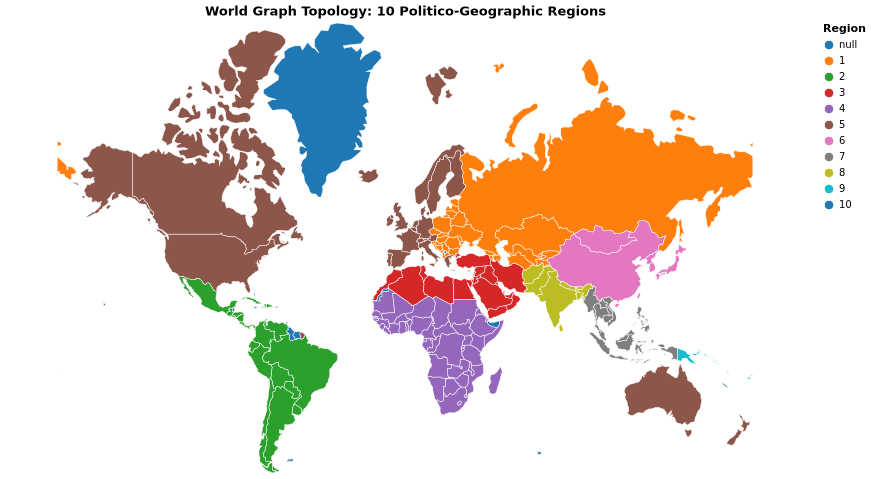

In [28]:
plt = @vlplot(
    data = clean_master,
    view = {projection = {type = :equalEarth}},
    width = 800, height = 450,
    title = "World Graph Topology: 10 Politico-Geographic Regions",
    layer = [
        {
            data = {
                values = dataset("world-110m"),
                format = {type = :topojson, feature = :countries}
            },
            transform = [
                # Drop Antarctica (try 10; if it doesn't work, use "010" below)
                {filter = "datum.id != 10"},
                {
                    lookup = :id,
                    from = {
                        data = clean_master,
                        key = :ccode,
                        fields = [:ht_region_fixed, :cname_fixed]
                    }
                }
            ],
            mark = {type = :geoshape, stroke = :white, strokeWidth = 0.5},
            color = {
                "ht_region_fixed:n",
                scale = {scheme = :category10},
                legend = {title = "Region"}
            },
            tooltip = [
                {field = "cname_fixed", type = "nominal", title = "Country"},
                {field = "ht_region_fixed", type = "quantitative", title = "Region"}
            ]
        }
    ]
)


## Special cases
From the above, we note that greenland is not tied to a region. This is due to the fact that it is not soveirgn and its data is tied to Denmark. Since we plan on using resource and landmass as part of a Mass variable calculation later, these must somehow be tied to our data for mapping, etc. To this effect, we review land masses

| Source / Link                             | Purpose                                                                                                                                                                         |
| ----------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Vega-Datasets (world-110m.json)**       | Provides the country geometry shapes and the numeric `id` field used to render map polygons in VegaLite.                                                                        |
| **UN Statistics Division (M49 Standard)** | Defines the official ISO 3166-1 numeric territory codes (`ccode`) and their corresponding country names. Serves as the authoritative identifier mapping layer.                  |
| **QoG Standard Codebook (PDF)**           | Defines the `ht_region` variable and its 10-category politico-geographic classification. Serves as the authoritative regional logic layer (see section *Geographic Variables*). |


In [29]:
using JSON, HTTP

# 1. Fetch the actual TopoJSON used by Vega to see the IDs it expects
topo_url = "https://raw.githubusercontent.com/vega/vega-datasets/main/data/world-110m.json"
response = HTTP.get(topo_url)
topo_data = JSON.parse(String(response.body))

# 2. Extract every unique 'id' from the geometry objects
# These IDs are the numeric ISO codes for every shape on the map
map_ids = Int[]
for feature in topo_data["objects"]["countries"]["geometries"]
    if haskey(feature, "id")
        push!(map_ids, feature["id"])
    end
end
unique_map_ids = unique(map_ids)

# 3. Load your current Master Infrastructure
country_master = CSV.read(country_region_path, DataFrame)
infrastructure_ids = collect(skipmissing(country_master.ccode))

# 4. Identify the "Ghost Nodes" (In Map, but not in your Data)
ghost_ids = setdiff(unique_map_ids, infrastructure_ids)

# 5. Output the Audit Trail
println("Found $(length(ghost_ids)) IDs in geometry with no data signal.")
println("Missing IDs: ", ghost_ids)

Found 9 IDs in geometry with no data signal.
Missing IDs: [10, 260, -99, 238, 304, 540, 630, 275, 732]


In [30]:
function resolve_iso_ids(ids)
    # Filter out geometry artifacts like -99
    valid_ids = filter(x -> x > 0, ids)
    
    results = DataFrame(ccode = Int[], Name = String[], Alpha3 = String[])
    
    for id in valid_ids
        # Pads ID with leading zeros if necessary (e.g., 4 -> 004)
        padded_id = lpad(id, 3, '0')
        url = "https://restcountries.com/v3.1/alpha/$(padded_id)"
        
        try
            res = HTTP.get(url)
            data = JSON.parse(String(res.body))[1]
            push!(results, (
                ccode = id, 
                Name = data["name"]["common"], 
                Alpha3 = data["cca3"]
            ))
        catch
            push!(results, (ccode = id, Name = "Manual Check Required", Alpha3 = "N/A"))
        end
    end
    return results
end

# Run against your ghost IDs
ghost_audit = resolve_iso_ids([10, 260, 238, 304, 540, 630, 275, 732])
println(ghost_audit)

8×3 DataFrame
 Row │ ccode  Name                               Alpha3 
     │ Int64  String                             String 
─────┼──────────────────────────────────────────────────
   1 │    10  Antarctica                         ATA
   2 │   260  French Southern and Antarctic La…  ATF
   3 │   238  Falkland Islands                   FLK
   4 │   304  Greenland                          GRL
   5 │   540  New Caledonia                      NCL
   6 │   630  Puerto Rico                        PRI
   7 │   275  Palestine                          PSE
   8 │   732  Western Sahara                     ESH


### Add these ccodes to our region mapping
We will intentionally exclude 10 and -99. This is specifically done to correct mapping. to regions and other data mapping later.

In [33]:
# 1. Define new territories matching your 4-column schema
# Excludes 10 (Antarctica) and -99 (Geometry artifact)
new_territories = DataFrame(
    ident_cname = ["Falkland Islands", "French Southern Territories", "Palestine", "Greenland", "New Caledonia", "Puerto Rico", "Western Sahara"],
    ident_ccode = [238, 260, 275, 304, 540, 630, 732],
    ident_ccodealp = ["FLK", "ATF", "PSE", "GRL", "NCL", "PRI", "ESH"],
    ht_region = [5, 5, 3, 5, 5, 5, 3]
)

# 2. Load existing CSV (Assumed to be promoted to ident_ namespace)
country_master = CSV.read(country_region_path, DataFrame)

# 3. Append and deduplicate by ident_ccode to ensure an idempotent run
# This ensures we don't double-add if the script is run twice
updated_master = unique(vcat(country_master, new_territories), :ident_ccode)

# 4. Save and Verify
CSV.write(country_region_path, updated_master)
println("Audit Complete. Updated master saved with $(nrow(updated_master)) entries.")

Audit Complete. Updated master saved with 206 entries.


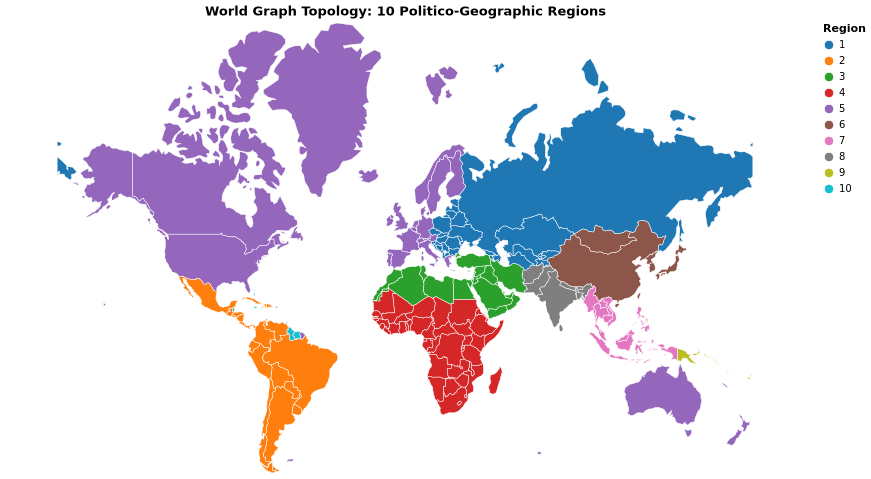

In [37]:
# Ensure your master is named correctly for the script
# If you used 'updated_master' in the previous step, set it here:
clean_master = updated_master 

plt = @vlplot(
    data = clean_master,
    view = {projection = {type = :equalEarth}},
    width = 800, height = 450,
    title = "World Graph Topology: 10 Politico-Geographic Regions",
    layer = [
        {
            data = {
                values = dataset("world-110m"),
                format = {type = :topojson, feature = :countries}
            },
            transform = [
                # Filter out Antarctica and the Null geometry
                {filter = "datum.id != 10"},
                {filter = "datum.id != -99"},
                {
                    lookup = :id,
                    from = {
                        data = clean_master,
                        key = :ccode,
                        fields = [:ht_region_fixed, :cname_fixed]
                    }
                }
            ],
            mark = {type = :geoshape, stroke = :white, strokeWidth = 0.5},
            color = {
                "ht_region_fixed:n",
                scale = {scheme = :category10},
                legend = {title = "Region"}
            },
            tooltip = [
                {field = "cname_fixed", type = "nominal", title = "Country"},
                {field = "ht_region_fixed", type = "nominal", title = "Region"}
            ]
        }
    ]
)

## Examine populations of regions

In [78]:
# 1. Target the baseline year
target_year = 2018

# 2. Extract 2018 population data using the promoted identity coordinates
# WPP data (World Population Prospects) is the analytical sensor here
pop_2018 = df_std[df_std.ident_year .== target_year, [:ident_cname, :wpp_pop]]
country_region_master = CSV.read(country_region_path, DataFrame)

# 3. Join with your Triple-Lock Master
# We join on the authoritative 'ident_cname' anchor. 
# makeunique=true is no longer necessary because our namespaces (ident_ vs wpp_) are isolated.
pop_mapped_2018 = leftjoin(
    pop_2018, 
    country_region_master, 
    on = :ident_cname
)

# 4. Aggregate by Region
# Note: Using the standardized, prefix-free 'ht_region'
region_mass_2018 = combine(groupby(pop_mapped_2018, :ht_region)) do sdf
    total_raw = sum(skipmissing(sdf.wpp_pop))
    (
        Pop_Millions_2018 = round(total_raw / 1000, digits=2),
        Country_Count = nrow(sdf)
    )
end

# 5. Final Merge with Labels
# Note: Ensure your region_labels table has been updated to use 'ht_region' as the key
final_2018_summary = leftjoin(region_mass_2018, region_labels, on = :ht_region)

# 6. Calculate Global Share (%)
# This represents the 'Mass' of the region within the Global (G) system
world_pop_2018 = sum(skipmissing(final_2018_summary.Pop_Millions_2018))
final_2018_summary.Global_Share_Pct = round.((final_2018_summary.Pop_Millions_2018 ./ world_pop_2018) .* 100, digits=2)

# Display sorted by the structural region code
sort!(final_2018_summary, :ht_region)

Row,ht_region,Pop_Millions_2018,Country_Count,Region_Name,Global_Share_Pct
,Int64?,Float64,Int64,String?,Float64
1,1,412.78,28,Eastern Europe and post Soviet Union (including Central Asia),5.43
2,2,622.03,20,"Latin America (including Cuba, Haiti & the Dominican Republic)",8.19
3,3,542.11,20,"North Africa & the Middle East (including Israel, Turkey & Cyprus)",7.13
4,4,1052.92,49,Sub-Saharan Africa,13.86
5,5,823.32,27,Western Europe and North America (including Australia & New Zealand),10.83
6,6,1624.0,6,East Asia (including Japan & Mongolia),21.37
7,7,659.8,11,South-East Asia,8.68
8,8,1842.73,8,South Asia,24.25
9,9,11.81,12,The Pacific (excluding Australia & New Zealand),0.16


## Audit prefix -> region fidelity

In [207]:
function audit_prefix_fidelity(df_std::DataFrame, manifest::DataFrame, prefix::String, target_year::Int=2018)
    # 1. Resolve Temporal Boundaries from Manifest
    # Find the maximum death year for all variables in this prefix
    prefix_meta = manifest[manifest.Prefix .== prefix, :]
    if isempty(prefix_meta)
        error("Prefix '$prefix' not found in manifest.")
    end
    
    max_death = maximum(skipmissing(prefix_meta.death_year))
    
    # 2. Determine Dynamic Audit Year
    # We audit at 2018, or the year the prefix died if it was earlier
    is_dead = max_death < target_year
    audit_year = is_dead ? Int(max_death) : target_year

    # 3. Isolate the Topological Snapshot
    df_snapshot = df_std[df_std.ident_year .== audit_year, :]
    prefix_cols = [c for c in names(df_snapshot) if startswith(string(c), prefix)]
    
    if isempty(prefix_cols)
        error("Prefix '$prefix' has no columns in df_std for year $audit_year.")
    end

    # 4. Determine Signal Density
    df_snapshot.has_signal = [any(!ismissing(r[c]) for c in prefix_cols) for r in eachrow(df_snapshot)]

    # 5. Aggregate Regional Fidelity
    regional_stats = combine(groupby(df_snapshot, :ht_region)) do sdf
        (
            Total_Countries = nrow(sdf),
            Signal_Countries = sum(sdf.has_signal),
            Fidelity_Pct = round((sum(sdf.has_signal) / nrow(sdf)) * 100, digits=1)
        )
    end

    # 6. Integrate Region Names
    audit_table = leftjoin(regional_stats, region_labels, on = :ht_region)

    # 7. Classification Logic (G/R/H)
    avg_f = mean(audit_table.Fidelity_Pct)
    std_f = std(audit_table.Fidelity_Pct)
    
    classification = if avg_f > 75 && std_f < 20
        "Global (G)"
    elseif std_f > 30 || (avg_f < 40 && any(audit_table.Fidelity_Pct .> 80))
        "Regional (R)"
    else
        "Hybrid (H)"
    end

    # 8. Append Global Total Line
    global_row = DataFrame(
        ht_region = 0,
        Region_Name = "GLOBAL TOTAL",
        Total_Countries = sum(audit_table.Total_Countries),
        Signal_Countries = sum(audit_table.Signal_Countries),
        Fidelity_Pct = round((sum(audit_table.Signal_Countries) / sum(audit_table.Total_Countries)) * 100, digits=1)
    )
    
    final_report = vcat(select(audit_table, [:ht_region, :Region_Name, :Total_Countries, :Signal_Countries, :Fidelity_Pct]), global_row)

    # 9. Final Output with Death Warning
    status_msg = is_dead ? "⚠️ INACTIVE (Died: $max_death)" : "✅ ACTIVE"
    
    println("\n--- Fidelity Audit: $prefix ($status_msg) ---")
    println("Snapshot Year: $audit_year")
    display(final_report)
    println("\nDetermined classification is: $classification")
    
    return final_report, classification
end

audit_prefix_fidelity (generic function with 4 methods)

In [208]:
audit_prefix_fidelity(df_std, manifest, "aid");


--- Fidelity Audit: aid (⚠️ INACTIVE (Died: 2013)) ---
Snapshot Year: 2013


Row,ht_region,Region_Name,Total_Countries,Signal_Countries,Fidelity_Pct
,Int64?,String?,Int64,Int64,Float64
1,1,Eastern Europe and post Soviet Union (including Central Asia),28,21,75.0
2,2,"Latin America (including Cuba, Haiti & the Dominican Republic)",19,19,100.0
3,3,"North Africa & the Middle East (including Israel, Turkey & Cyprus)",20,14,70.0
4,4,Sub-Saharan Africa,49,48,98.0
5,5,Western Europe and North America (including Australia & New Zealand),27,22,81.5
6,6,East Asia (including Japan & Mongolia),7,6,85.7
7,7,South-East Asia,11,9,81.8
8,8,South Asia,8,8,100.0
9,9,The Pacific (excluding Australia & New Zealand),12,12,100.0



Determined classification is: Global (G)


# Work in progess

In [43]:
df_std = load_qog(timeseries_path, country_region_path, validity_mask_path);

QoG Dataset Initialized: 12391 rows x 2010 columns


In [45]:
base_vars = filter(v -> startswith(String(v), "base_"), propertynames(df_std))
println("Confirmed base identifiers: ", base_vars)

Confirmed base identifiers: [:base_cname, :base_year, :base_ccodealp, :base_ccode]


In [47]:
df = Arrow.Table(timeseries_path) |> DataFrame;

In [48]:
base_vars = filter(v -> startswith(String(v), "base_"), propertynames(df))
println("Confirmed base identifiers: ", base_vars)

Confirmed base identifiers: Symbol[]


In [6]:
manifest_df = CSV.read(manifest_result_path, DataFrame);

In [47]:
# Step 1: Group by Prefix and check regional breadth
global_audit = combine(groupby(manifest_df, :Prefix)) do p_df
    # 1. Identify variables belonging to this prefix that are in our cleaned df_std
    prefix_vars = intersect(p_df.Variable, names(df_std))
    
    if isempty(prefix_vars)
        return (regions_found = 0, is_global = false)
    end

    # 2. FIX: Ensure unique selection to avoid ArgumentError when Prefix is "ht"
    target_cols = unique(vcat(prefix_vars, ["ht_region"]))
    sub_df = df_std[df_std.is_valid .== 1, target_cols]
    
    # 3. Determine row-wise existence of data for this slug family
    # We use prefix_vars only for the check, excluding "ht_region" from the 'any' logic
    has_data = any.(.!ismissing, eachrow(view(sub_df, :, prefix_vars)))
    
    # 4. Count unique instances of your FIXED region codes for active rows
    active_regions = sub_df[has_data, "ht_region"]
    unique_regions = unique(skipmissing(active_regions))
    n_regions = length(unique_regions)
    
    # Classification: Must reach all 10 of your fixed region codes
    (regions_found = n_regions, is_global = (n_regions == 10))
end

# Lock the list of "Definitely Global" prefixes
global_prefixes = global_audit[global_audit.is_global, :Prefix]

90-element PooledArrays.PooledVector{String15, UInt32, Vector{UInt32}}:
 "cname"
 "base"
 "ccodealp"
 "ccode"
 "aid"
 "atop"
 "bci"
 "bicc"
 "biu"
 "bl"
 "bmr"
 "br"
 "cai"
 ⋮
 "une"
 "van"
 "vdem"
 "warc"
 "wbgi"
 "wdi"
 "wgov"
 "who"
 "wpp"
 "wui"
 "wwbi"
 "yri"

In [51]:
# 1. Identify non-global prefixes from our previous audit
non_global_prefixes = global_audit[.!global_audit.is_global, :Prefix]

# 2. Audit all non-global prefixes with consistent return types
regional_audit_full = combine(groupby(manifest_df[in(non_global_prefixes).(manifest_df.Prefix), :], :Prefix)) do p_df
    prefix_vars = intersect(p_df.Variable, names(df_std))
    
    # Handle prefixes with no variables in df_std
    if isempty(prefix_vars)
        return (Regions_Found = 0, Region_List = "")
    end

    # Check rows marked valid in your mask
    sub_df = df_std[df_std.is_valid .== 1, vcat(prefix_vars, ["ht_region"])]
    has_data = any.(.!ismissing, eachrow(view(sub_df, :, prefix_vars)))
    
    # Extract fixed region codes for active rows
    active_regions = sort(unique(skipmissing(sub_df[has_data, "ht_region"])))
    n_regions = length(active_regions)
    
    return (
        Regions_Found = n_regions, 
        Region_List = join(active_regions, ",")
    )
end

# 3. Final Step: Filter specifically for "Definitely Regional" (1-3 regions)
definitely_regional = filter(row -> 1 <= row.Regions_Found <= 3, regional_audit_full)

println("Definitely Regional List Compiled: $(nrow(definitely_regional)) prefixes found.")
definitely_regional

Definitely Regional List Compiled: 9 prefixes found.


Row,Prefix,Regions_Found,Region_List
,String15,Int64,String
1,aii,2,"3,4"
2,cri,3,"1,3,5"
3,dev,2,"3,5"
4,ess,3,"1,3,5"
5,evep,3,"1,3,5"
6,gtr,3,"2,5,6"
7,iiag,2,"3,4"
8,mibu,3,"1,3,5"
9,psi,2,"3,5"


In [52]:
# Inspect the actual regional footprint of the 'eu' prefix
eu_vars = intersect(manifest_df[manifest_df.Prefix .== "eu", :Variable], names(df_std))
eu_data = df_std[df_std.is_valid .== 1, vcat(eu_vars, ["ht_region"])]
has_eu_data = any.(.!ismissing, eachrow(view(eu_data, :, eu_vars)))

# Count how many regions actually have 'eu' data points
eu_regions = sort(unique(skipmissing(eu_data[has_eu_data, "ht_region"])))
println("Prefix 'eu' found in regions: ", join(eu_regions, ", "))
println("Total regions for 'eu': ", length(eu_regions))

Prefix 'eu' found in regions: 1, 2, 3, 4, 5, 6, 7, 8
Total regions for 'eu': 8


In [53]:
# Refined Step 2: Regionality by Data Saturation
using StatsBase

regional_saturation = combine(groupby(manifest_df[in(non_global_prefixes).(manifest_df.Prefix), :], :Prefix)) do p_df
    prefix_vars = intersect(p_df.Variable, names(df_std))
    if isempty(prefix_vars) return (is_regional = false, primary_regions = "") end

    # 1. Isolate the signal rows
    active_mask = any.(.!ismissing, eachrow(view(df_std, :, prefix_vars))) .& (df_std.is_valid .== 1)
    
    # 2. Map the frequency of your FIXED region codes
    regional_counts = countmap(df_std[active_mask, "ht_region"])
    total_obs = sum(values(regional_counts))
    
    # 3. Define the Primary Footprint (Regions holding > 5% of total prefix data)
    # This 5% filter strips out the 'Long Tail' leakage you saw in regions 2, 4, 6, 7, 8
    primary_regions = sort([r for (r, count) in regional_counts if (count / total_obs) > 0.05])
    
    n_primary = length(primary_regions)
    
    # Classification: 1-3 primary regions = Definitely Regional
    (is_regional = 1 <= n_primary <= 3, primary_regions = join(primary_regions, ","))
end

# Lock the refined Regional Subsystem list
definitely_regional = filter(row -> row.is_regional, regional_saturation)

Row,Prefix,is_regional,primary_regions
,String15,Bool,String
1,aii,true,"3,4"
2,cpds,true,"1,5"
3,cri,true,"1,5"
4,dev,true,5
5,ess,true,"1,3,5"
6,eu,true,"1,3,5"
7,evep,true,"1,5"
8,gfs,true,"1,3,5"
9,gtr,true,"2,5"


In [55]:
using DataFrames, StatsBase

# 1. Run the unified topological audit
topology_audit = combine(groupby(manifest_df, :Prefix)) do p_df
    prefix = p_df.Prefix[1]
    prefix_vars = intersect(p_df.Variable, names(df_std))
    
    if isempty(prefix_vars)
        return (Category = "Empty", Region_Display = "")
    end

    # 2. Corrected selection: Ensure "ht_region" is only included once
    # This prevents the ArgumentError for the 'ht' prefix
    target_cols = unique(vcat(prefix_vars, ["ht_region"]))
    sub_df = df_std[df_std.is_valid .== 1, target_cols]
    
    # 3. Determine row-wise existence for the family
    has_data = any.(.!ismissing, eachrow(view(sub_df, :, prefix_vars)))
    
    # 4. Calculate saturation on your FIXED region codes
    regional_counts = countmap(sub_df[has_data, "ht_region"])
    total_obs = sum(values(regional_counts))
    
    # Identify Primary Regions (Saturation > 5%)
    # This filter strips the 'long tail' noise seen in the 'eu' prefix
    primary_regions = sort([r for (r, count) in regional_counts if (count / total_obs) > 0.05])
    n_primary = length(primary_regions)
    region_str = join(primary_regions, ", ")

    # 5. Categorization Logic
    # Global = 10/10 | Regional = 1-3 | Hybrid = 4-9
    category = if n_primary == 10
        "Global"
    elseif 1 <= n_primary <= 3
        "Regional"
    elseif 4 <= n_primary <= 9
        "Hybrid"
    else
        "Trace"
    end
    
    return (Category = category, Region_Display = "($region_str)")
end

# Lock classifications
sort!(topology_audit, [:Category, :Prefix])

Row,Prefix,Category,Region_Display
,String15,String,String
1,aid,Hybrid,"(1, 2, 3, 4, 5, 7, 8, 9, 10)"
2,ajr,Hybrid,"(2, 4, 5, 7, 8, 10)"
3,atop,Hybrid,"(1, 2, 3, 4, 5, 7, 10)"
4,base,Hybrid,"(1, 2, 3, 4, 5, 7, 10)"
5,bci,Hybrid,"(1, 2, 3, 4, 5, 7, 10)"
6,bicc,Hybrid,"(1, 2, 3, 4, 5, 7)"
7,biu,Hybrid,"(1, 2, 3, 4, 5, 7)"
8,bl,Hybrid,"(1, 2, 3, 4, 5, 7, 8)"
9,bmr,Hybrid,"(1, 2, 3, 4, 5, 7, 10)"


In [56]:
# Verify the unique prefix count in your manifest
unique_prefixes = unique(manifest_df.Prefix)
println("Total Unique Prefixes in Manifest: ", length(unique_prefixes))

# Optional: View the list to ensure no 'unknown' or 'missing' entries are skewing the count
println(unique_prefixes)

Total Unique Prefixes in Manifest: 119
String15["cname", "base", "ccodealp", "ccode", "aid", "aii", "ajr", "atop", "bci", "bicc", "biu", "bl", "bmr", "br", "bti", "cai", "cam", "cbi", "cbie", "ccp", "chga", "chisols", "ciri", "cpds", "cri", "cses", "cspf", "dev", "diat", "dr", "ef", "egov", "epi", "ess", "eu", "evep", "fao", "fe", "fh", "fhn", "fhp", "fi", "gain", "gc", "gcb", "gea", "gendip", "gfs", "gggi", "gle", "gol", "gpcr", "gpi", "gted", "gti", "gtm", "gtr", "gwf", "h", "hief", "hrv", "ht", "iaep", "ibp", "icd", "icrg", "ictd", "ideaesd", "ideavt", "idf", "ied", "ihme", "iiag", "ipu", "jw", "kun", "lis", "lld", "mad", "mibu", "nelda", "nrmi", "oecd", "ohi", "opri", "p", "pei", "prp", "psi", "pwt", "qar", "rd", "ross", "rsf", "sai", "sgi", "spi", "ti", "top", "ucdp", "undp", "une4", "une", "van", "vdem", "warc", "wbgi", "wdi", "wef", "wgov", "who", "whr", "wjp", "wpp", "wr", "wui", "wvs", "wwbi", "yri"]


In [57]:
using DataFrames, CSV

# 1. Define the Ground Truth Map
definitions = DataFrame(
    Prefix = [
        # Regional by Definition
        "aii", "cpds", "cri", "dev", "ess", "eu", "evep", "gfs", "gtr", 
        "iiag", "lis", "mibu", "psi", "sgi", "asbar", "afrobarometer", "lapop",
        # Global by Definition
        "wdi", "wpp", "vdem", "fh", "pwt", "gle", "polcon", "p_polity5", 
        "unum", "bmr", "chga", "dpi", "gd", "gol", "h", "j_p", "j_r", 
        "nelda", "mad", "mad_ang"
    ],
    Def_Category = [
        # Regional labels
        fill("Regional", 17)..., 
        # Global labels
        fill("Global", 20)...
    ],
    Def_Regions = [
        # Regional Footprints
        "(3, 4)", "(1, 5)", "(1, 3, 5)", "(5)", "(1, 3, 5)", "(1, 3, 5)", "(1, 5)", 
        "(1, 3, 5)", "(2, 5)", "(3, 4)", "(1, 2, 5)", "(1, 3, 5)", "(5)", "(1, 3, 5)",
        "(6, 7, 8)", "(4)", "(2)",
        # Global Footprints (Always 1-10)
        fill("(1-10)", 20)...
    ]
)

Row,Prefix,Def_Category,Def_Regions
,String,String,String
1,aii,Regional,"(3, 4)"
2,cpds,Regional,"(1, 5)"
3,cri,Regional,"(1, 3, 5)"
4,dev,Regional,(5)
5,ess,Regional,"(1, 3, 5)"
6,eu,Regional,"(1, 3, 5)"
7,evep,Regional,"(1, 5)"
8,gfs,Regional,"(1, 3, 5)"
9,gtr,Regional,"(2, 5)"


In [58]:
# 2. Merge with your Empirical Audit results
final_topology = leftjoin(topology_audit, definitions, on=:Prefix)

# 3. Reconcile: Priority 1: Definitions | Priority 2: Empirical
final_topology.Final_Category = [
    !ismissing(row.Def_Category) ? row.Def_Category : row.Category 
    for row in eachrow(final_topology)
]

# Ensure Global prefixes have the (1-10) string, otherwise use empirical display
final_topology.Final_Regions = [
    !ismissing(row.Def_Regions) ? row.Def_Regions : row.Region_Display 
    for row in eachrow(final_topology)
]

# 4. Filter and select clean columns
output_manifest = select(final_topology, 
    :Prefix, 
    :Final_Category => :Topology, 
    :Final_Regions => :Region_Footprint
)

Row,Prefix,Topology,Region_Footprint
,String15,String,String
1,bmr,Global,(1-10)
2,chga,Global,(1-10)
3,fh,Global,(1-10)
4,gle,Global,(1-10)
5,gol,Global,(1-10)
6,h,Global,(1-10)
7,mad,Global,(1-10)
8,nelda,Global,(1-10)
9,pwt,Global,(1-10)


In [59]:
# Save to your result path
CSV.write("data/ggis_prefix_topology_master.csv", output_manifest)

println("Master Topology File Saved: $(nrow(output_manifest)) prefixes categorized.")

Master Topology File Saved: 119 prefixes categorized.


In [60]:
# Isolate the 'who' prefix variables
who_vars = intersect(manifest_df[manifest_df.Prefix .== "who", :Variable], names(df_std))

# Extract the footprint using your fixed regions
who_data = df_std[df_std.is_valid .== 1, unique(vcat(who_vars, ["ht_region"]))]
has_who_data = any.(.!ismissing, eachrow(view(who_data, :, who_vars)))

# Calculate saturation
who_regional_counts = countmap(who_data[has_who_data, "ht_region"])
who_total = sum(values(who_regional_counts))

# Identify regions with > 5% of the data
who_primary_regions = sort([r for (r, count) in who_regional_counts if (count / who_total) > 0.05])

println("WHO Prefix found in regions (raw): ", sort(unique(skipmissing(who_data[has_who_data, "ht_region"]))))
println("WHO Primary Regions (>5%): ", who_primary_regions)

WHO Prefix found in regions (raw): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
WHO Primary Regions (>5%): [1, 2, 3, 4, 5, 7, 10]


# Copied Out Functions and Remarks

In [217]:
# function load_raw_ident(timeseries_path)
#     # 1. Load Main Data
#     df = Arrow.Table(timeseries_path) |> DataFrame
    
#     # 2. Explicit Identity Transformation (Section 3 of Codebook)
#     # Promoted to the 'ident_' namespace to distinguish coordinates from data.
#     identity_transform = Dict(
#         :ccode         => :ident_ccode,        # 3.0.1
#         :ccode_qog     => :ident_ccode_qog,    # 3.0.2
#         :ccodealp      => :ident_ccodealp,     # 3.0.3
#         :ccodealp_year => :ident_ccodealp_year,# 3.0.4
#         :ccodecow      => :ident_ccodecow,     # 3.0.5
#         :ccodewb       => :ident_ccodewb,      # 3.0.6
#         :cname         => :ident_cname,        # 3.0.7
#         :cname_qog     => :ident_cname_qog,    # 3.0.8
#         :cname_year    => :ident_cname_year,   # 3.0.9
#         :version       => :ident_version,      # 3.0.10
#         :year          => :ident_year          # 3.0.11
#     )
    
#     # Execute transformation ONLY for variables present in the specific Arrow file
#     actual_ident_vars = Dict(k => v for (k, v) in identity_transform if k in propertynames(df))
#     rename!(df, actual_ident_vars)

#     # Note: ht_region is deliberately left without a prefix per your instruction.
    
#     return df
# end

## Prefix Schema for the World Graph Data Model

This project uses a strict prefix schema to enforce namespace integrity, auditability, and clear separation between identity, operational logic, and observational data.

---

### 1. The `ident_` Prefix — Topological Coordinates

**Category:** Identity / Dimensions  
**Classification:** Global (G)

The `ident_` prefix is reserved for the Identification Variables defined in Section 3 of the Quality of Government (QoG) Codebook. These variables represent the *“Where”* and *“When”* of the model.

**Purpose:**  
To isolate the coordinate system from the data mass.

**Engineering Benefit:**  
Prevents `ArgumentError: Duplicate variable names` during joins. By renaming raw keys (such as `ccode`) to `ident_ccode` immediately upon ingestion, a protected namespace is created that external data sources cannot overwrite.

**Audit Logic:**  
Any column with this prefix is a **Dimension**, not a Measurement. It is used for grouping and merging, never for calculating indices.

**Protected Keys:**  
`ident_cname`, `ident_ccode`, `ident_ccodealp`, `ident_year`, etc.

---

### 2. The `ggis_` Prefix — Operational Intelligence

**Category:** Custom Logic / Quality Control  
**Classification:** Global (G)

The `ggis_` prefix identifies variables, flags, and indices created specifically for this project’s internal methodology.

**Purpose:**  
To distinguish original research and data-cleaning logic from source-provider data (e.g., World Bank, V-Dem).

**Engineering Benefit:**  
Provides instant scannability of project-specific metrics.  
Example:  
`select(df, StartsWith("ggis_"))` immediately reveals validity gates and criticality scores generated by internal functions.

**Audit Logic:**  
These are **Operational Gates**. For example, `ggis_isvalid` acts as a binary switch determining whether a ident_cc is considered as existing during a given ident_year.

---

### 3. The `[source]_` Prefix — Analytical Sensors

**Category:** Observations / Measurements  
**Classification:** Global / Regional / Hybrid (Requires Audit)

Any variable that does not establish identity or operational logic belongs to its institutional source prefix (e.g., `wdi_`, `vdem_`, `who_`).

**Purpose:**  
To preserve data provenance.

**Audit Logic:**  
These variables are subjected to the Global / Regional / Hybrid fidelity audit. Unlike `ident_` variables, they are expected to exhibit **signal decay** depending on region and sampling frame.

---

### Summary: Triple-Tier Schema

| Prefix | Tier | Functional Role | Data Type |
|--------|------|-----------------|-----------|
| `ident_` | Identity | World Graph Coordinates | Categorical / String / ID |
| `ggis_` | Operational | Internal Logic & Quality Gates | Boolean / Index / Float |
| `[source]_` | Analytical | Source-Provided Observations | Measurement / Sensor Data |

---

### Note on `ht_region`

Per system requirements, the politico-geographic region variable **`ht_region` remains prefix-free**.

It acts as the primary **Anchor Cluster** between the Identity layer and the Analytical layer.


In [299]:
# """
# Validate the ident schema of all adjunct files prior to them being used to augment our raw time series

# Call: validate_ident_schema(file_path)
# """
# function validate_ident_schema(file_path::String)
#     # 1. Peek at the headers
#     if endswith(file_path, ".arrow")
#         df_header = Arrow.Table(file_path) |> DataFrame |> d -> first(d, 0)
#     else
#         df_header = CSV.read(file_path, DataFrame, limit=0)
#     end
    
#     # 2. Define the Core Identity Pattern
#     # This regex matches any string containing your specific codebook keys
#     # e.g., 'ccode', 'cname', 'year', 'version'
#     id_pattern = r"(^|_)(ccode|cname|year|version)(_|$)"
    
#     current_vars = String.(propertynames(df_header))
#     violations = String[]
#     warnings = String[]

#     # 3. Active Scan
#     for var in current_vars
#         lvar = lowercase(var)
        
#         if occursin(id_pattern, lvar)
#             # Tier 1: Strict Compliance
#             if startswith(var, "ident_") || var == "ht_region"
#                 continue
            
#             # Tier 2: Internal Logic (Warning but Pass)
#             elseif startswith(var, "ggis_")
#                 push!(warnings, var)
#                 continue
            
#             # Tier 3: Unauthorized (Block)
#             else
#                 push!(violations, var)
#             end
#         end
#     end
    
#     # 4. Reporting
#     if !isempty(warnings)
#         println("⚠️  SCHEMA WARNING: $file_path")
#         println("   Internal logic variables detected: $warnings")
#     end

#     if !isempty(violations)
#         println("\n❌ SCHEMA VIOLATION: $file_path")
#         println("   The following variables must be promoted to the 'ident_' namespace:")
#         println("   $violations")
#         return false # Block the load
#     end
    
#     println("✓ Namespace verified: $file_path")
#     return true
# end

In [278]:
# function create_validity_mask(timeseries_path, validity_mask_path)
#     df = load_raw_ident(timeseries_path)

#     if !(:ident_ccode in propertynames(df))
#         error("Structural Failure: 'ident_ccode' not found in source. Check IDENT_MAPPING.")
#     end
    
#     # 1. Generate the Validity Adjunct
#     # select() handles Symbols perfectly
#     validity_adjunct = select(df, :ident_ccodealp, :ident_year)
    
#     # 2. Vectorized check (1 if exists, 0 if missing)
#     validity_adjunct.ggis_isvalid = Int8.(.!ismissing.(df.ident_ccode))
    
#     # 3. Save as CSV for auditing and portability
#     # CSV.write(validity_mask_path, validity_adjunct)

#     # 4. Diagnostic Feedback
#     valid_count = sum(validity_adjunct.ggis_isvalid)
#     total_count = nrow(validity_adjunct)
#     total_rows = nrow(df)
    
#     println("✓ Validity mask saved to: ", validity_mask_path)
#     println("  - Anchor: ident_ccodealp")
#     println("  - Saturation: $valid_count / $total_count of $total_rows rows marked as valid.")
#     println("  - Schema: ", names(validity_adjunct))
#     return validity_adjunct
# end

# # create_validity_mask(PATH_TS_RAW, PATH_VALIDITY_MASK)

In [296]:
# function load_qog(timeseries_path, country_region_path, validity_mask_path)
#     # 0. Namespace Verification
#     for adjunct in [country_region_path, validity_mask_path]
#         if !validate_ident_schema(adjunct)
#             error("Load aborted: $adjunct violates namespace standards.")
#         end
#     end
    
#     # 1. Identity Promotion & Regional Reconstruction
#     df = load_raw_ident(timeseries_path)
#     regions = CSV.read(country_region_path, DataFrame)
    
#     # Numeric Alignment (Numeric Lock)
#     df.ident_ccode = passmissing(x -> Int64(round(x))).(df.ident_ccode)
#     regions.ident_ccode = passmissing(x -> Int64(round(x))).(regions.ident_ccode)
    
#     # Native Eviction Rule
#     if :ht_region in propertynames(df)
#         select!(df, Not(:ht_region))
#     end
    
#     df = leftjoin(df, select(regions, [:ident_ccode, :ht_region]), 
#                   on = :ident_ccode, matchmissing=:equal)
    
#     # 2. Operational Intelligence (The Mask)
#     mask = CSV.read(validity_mask_path, DataFrame)
#     if :ht_region in names(mask) select!(mask, Not(:ht_region)) end
    
#     df = leftjoin(df, mask, on = [:ident_ccodealp, :ident_year], matchmissing=:equal)

#     # 3. Final Diagnostic Check (The Coalesce Shield)
#     # We check if any VALID nodes (ggis_isvalid == 1) are missing a region
#     is_valid_but_unmapped = (df.ggis_isvalid .== 1) .& ismissing.(df.ht_region)
#     critical_leakage = df[coalesce.(is_valid_but_unmapped, false), :]
    
#     if nrow(critical_leakage) > 0
#         println("⚠️  LEAKAGE: Found $(nrow(critical_leakage)) valid country-years with no region.")
#     else
#         println("✓ Success: All valid nodes are mapped to regions.")
#     end

#     return df
# end

In [317]:
# using ReadStatTables

# """
#     generate_raw_manifest(raw_dta_path::String, output_csv::String)

# The Genesis Step: Extracts metadata labels and defines initial prefixes directly 
# from the raw Stata source. 

# Prefix Logic:
# - Variables with '_' are assigned their lead string (e.g., 'wdi_life' -> 'wdi').
# - Naked variables (ccode, year) are tagged as 'base' for later 'ident_' promotion.
# """
# function generate_raw_manifest(raw_dta_path::String, output_csv::String)    
#     # 1. High-Fidelity Metadata Extraction
#     # We use readstatallmeta to get the full positional mapping
#     _, var_names, var_metas, _ = ReadStatTables.readstatallmeta(raw_dta_path)

#     meta_entries = NamedTuple[]

#     # 2. Iterate through the raw structure
#     for (i, v) in enumerate(var_names)
#         v_str = String(v)
#         vm = var_metas[i]

#         # Extract Label with a safe fallback
#         lbl = haskey(vm, "label") ? vm["label"] : "No Label Found"

#         # Prefix Assignment: 
#         # This is critical for Layer 3 (Fidelity Auditing).
#         # 'base' flags variables that establish the coordinate system (ccode, year).
#         prefix = if occursin("_", v_str)
#             split(v_str, "_")[1]
#         else
#             "base"
#         end

#         push!(meta_entries, (
#             Variable = v_str, 
#             Label = lbl, 
#             Prefix = prefix,
#         ))
#     end

#     # 3. Persistence
#     df_manifest = DataFrame(meta_entries)
#     # CSV.write(output_csv, df_manifest)

#     println("✓ Raw Manifest Created: $output_csv")
#     println("  - Extracted $(nrow(df_manifest)) raw definitions.")
#     println("  - Identified $(length(unique(df_manifest.Prefix))) unique source prefixes.")
    
#     return df_manifest
# end